In [264]:
import os
os.environ["PROJ_IGNORE_CELESTIAL_BODY"]="YES"
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

In [265]:
data = pd.read_csv('RAOBs_201903131200.txt',sep=',',header=None)
#print (data) #sanity check

In [266]:
latitude = data[1]
longitude = data[2]
h500 = data[3]
d500 = data[4] #don't actually need
s500 = data[5] #don't actually need
#print (longitude,h500,d500,s500) #sanity check

In [267]:
#define constants and set up grid
nx,ny=(21, 27) #set up grid
x0=25 #initial x and y
y0=-15.5
rho=6371000 # earth's radius
m=1/15000000 #scale factor
phi0=60
lambda0=-100

yv=y0+(np.arange(ny))*1.27 # x and y coordinates of grid points, spaced 1.27cm apart
xv=x0+(np.arange(nx))*1.27
xcm, ycm=np.meshgrid(xv,yv, indexing='ij') #create grid
#plt.plot(ycm,xcm,marker='.',color='k',linestyle='none') #hooray it's a grid!

x=xcm/100/m
y=ycm/100/m
r=np.sqrt(x**2+y**2)


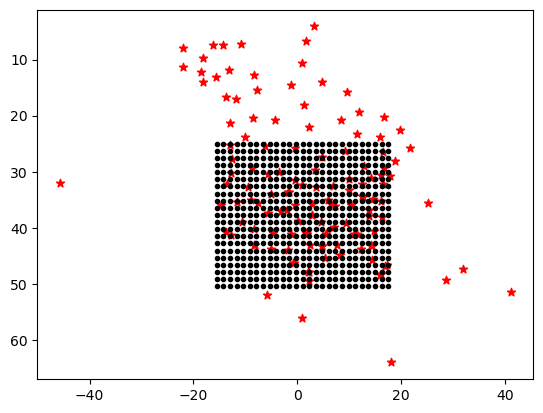

In [268]:
#lat lon to x y
psi0=90-phi0 #psi in degrees

#for the love of god eliza keep better track of what's in degrees and what's in radians

phi=np.pi/2-2*np.arctan(r/(rho*(1+np.cos(np.radians(psi0))))) #phi in RADIANS
lam=np.arctan2(y,x) 
gridlat=np.degrees(phi) #grid points lat
gridlon=(lambda0+np.degrees(lam)+180)%360-180 #grid points lon
#print (lat)
#print(lon) #sanity check
phi=np.radians(latitude)
lam=np.radians(longitude-lambda0)

sigma=(1+np.sin(np.radians(phi0)))/(1+np.sin(phi)) #
R=m*sigma*rho*np.cos(phi)
X=100*R*np.cos(lam)
Y=100*R*np.sin(lam)

plt.plot(ycm,xcm,marker='.',color='k',linestyle='none')
plt.gca().invert_yaxis() #bc points were inverted on grid :( STOP DOING THAT

#print (lon)
#print (ycm) #sanity check
plt.scatter(Y,X,marker='*',color='r') #bc X IS Y AND Y IS X. I have big feelings about the choice of x and y directions
plt.show()

In [269]:
#height analysis for ROI=10
(i)=(((xcm-x0)/1.27)).astype(int) #set up indices
(j)=((ycm-y0)/1.27).astype(int)

ROI=[10] #for 10km region of influence
#sanity check
#print (xcm[i,j])
#sanity check conclusion: its gone :(
#xcm,ycm are grid, h500 is 500 height values

amatrix10=np.full((21,27,1),np.nan) #analysis matrix for ROI10
observed10=np.zeros((21,27,1),dtype=int) #number of observations for ROI10

for r,ROIo in enumerate(ROI):
    for i in range(21): #iterate over i
        for j in range(27): #over j, ensures running analysis for each grid point
            xi=xcm[i,j] # x coordinates for all grid points
            yi=ycm[i,j] # y coordinates for all grid points
            dfpx=X-xi # x distance between grid point and obs
            dfpy=Y-yi # y distance between grid point and obs
            d=np.sqrt(dfpx**2+dfpy**2) #shortest distance between point and obs
            inregion=d<10 #check if within region of influence
            count=sum(inregion) #to keep track of how many points are in ROI
            observed10[i,j,r]=count
            xk=dfpx[inregion] #observation locations in radius of influence
            yk=dfpy[inregion]
            fk=h500[inregion]
            mat=np.column_stack([np.ones_like(xk),xk,yk,xk**2,yk**2,xk*yk]) #from general analysis equation
            a=np.array([[np.mean(mat[:,p]*mat[:,q]) for q in range(6)] for p in range(6)])
            b=np.array([np.mean(mat[:,p]*fk) for p in range(6)])
            #solve by inverting a and multiplying
            inva=np.linalg.inv(a)
            c=inva@b

            amatrix10[i,j,r]=c[0]
            #print (amatrix) #sanity check
#with np.printoptions(threshold=np.inf, linewidth=np.inf):
    #print(amatrix)          

/opt/anaconda3/envs/atsc528/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/atsc528/lib/python3.10/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


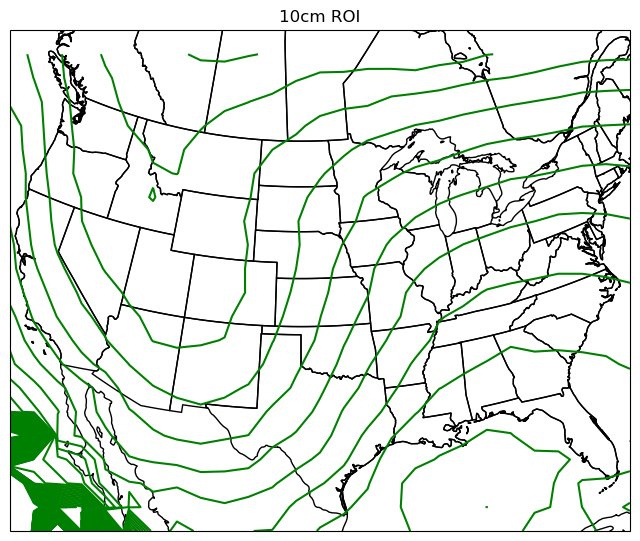

In [270]:
### Plot number of observations available to polynomial fitting scheme for each grid point ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho/100, semiminor_axis=rho/100)
proj = ccrs.Stereographic(central_longitude=lambda0,central_latitude=90,true_scale_latitude=phi0, globe=globe)

fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(111,projection=proj)
#ax1.set_extent([-120,-75,25,50],crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #

cs1 = ax1.contour(gridlon,gridlat,amatrix10[:,:,0],colors='g',levels=np.arange(0,8000,60),transform=ccrs.PlateCarree(globe=globe))
#plt.clabel(cs1,levels=np.arange(0,200,10))
plt.title("10cm ROI")

plt.show()

/opt/anaconda3/envs/atsc528/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/atsc528/lib/python3.10/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


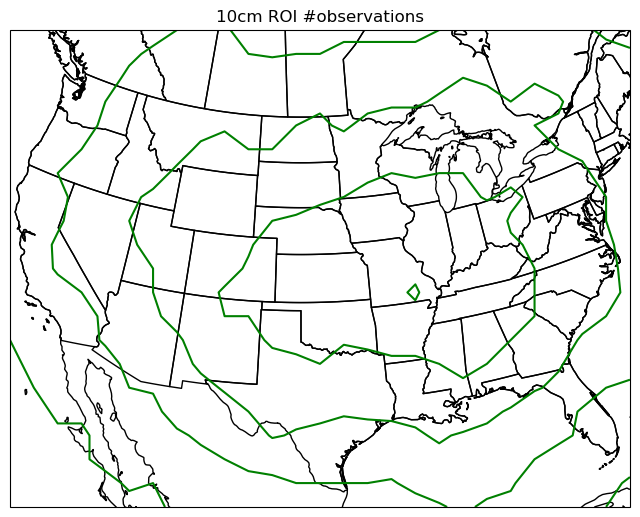

In [271]:
#plot number observations
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho/100, semiminor_axis=rho/100)
proj = ccrs.Stereographic(central_longitude=lambda0,central_latitude=90,true_scale_latitude=phi0, globe=globe)

fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(111,projection=proj)
#ax1.set_extent([-120,-75,25,50],crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #

cs1 = ax1.contour(gridlon,gridlat,observed10[:,:,0],colors='g',levels=np.arange(0,200,10),transform=ccrs.PlateCarree(globe=globe))
#plt.clabel(cs1,levels=np.arange(0,200,10))
plt.title("10cm ROI #observations")

plt.show()

In [272]:
#analysis for ROI=20
ROI=[20]

amatrix20=np.full((21,27,1),np.nan)
observed20=np.zeros((21,27,1),dtype=int)

for r,ROIo in enumerate(ROI):
    for i in range(21): #iterate over i
        for j in range(27): #iterate over j, nested for loops for analyzing every grid point
            xi=xcm[i,j]
            yi=ycm[i,j]
            dfpx=X-xi # x axis distance between obs and grid
            dfpy=Y-yi # y axis distance between obs and grid
            d=np.sqrt(dfpx**2+dfpy**2) #find distance from grid points to obs points
            inregion=d<20 #determine if observed point close enough to matter
            count=sum(inregion)
            observed20[i,j,r]=count #keeps track of how many points are in region of influence for each grid point
            xk=dfpx[inregion]
            yk=dfpy[inregion]
            fk=h500[inregion]
            mat=np.column_stack([np.ones_like(xk),xk,yk,xk**2,yk**2,xk*yk])
            a=np.array([[np.mean(mat[:,p]*mat[:,q]) for q in range(6)] for p in range(6)])
            b=np.array([np.mean(mat[:,p]*fk) for p in range(6)])
            inva=np.linalg.inv(a)
            c=inva@b

            amatrix20[i,j,r]=c[0]
            #print (amatrix) #sanity check
#with np.printoptions(threshold=np.inf, linewidth=np.inf):
    #print(amatrix)          

/opt/anaconda3/envs/atsc528/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/atsc528/lib/python3.10/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


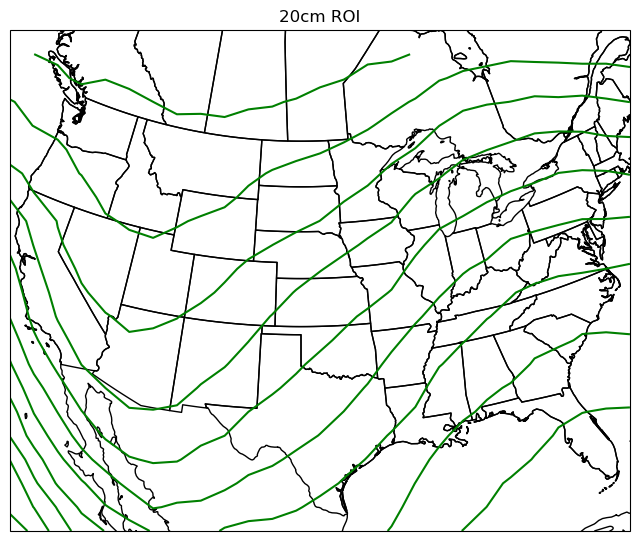

In [273]:
### Plot number of observations available to polynomial fitting scheme for each grid point ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho/100, semiminor_axis=rho/100)
proj = ccrs.Stereographic(central_longitude=lambda0,central_latitude=90,true_scale_latitude=phi0, globe=globe)

fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(111,projection=proj)
#ax1.set_extent([-120,-75,25,50],crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #

cs1 = ax1.contour(gridlon,gridlat,amatrix20[:,:,0],colors='g',levels=np.arange(0,8000,60),transform=ccrs.PlateCarree(globe=globe))
#plt.clabel(cs1,levels=np.arange(0,200,10))
plt.title("20cm ROI")

plt.show()

/opt/anaconda3/envs/atsc528/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/atsc528/lib/python3.10/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


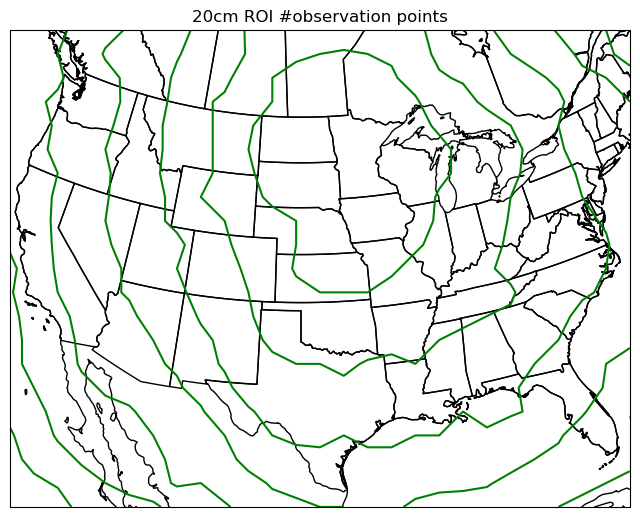

In [274]:
#plot # observations for ROI20
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho/100, semiminor_axis=rho/100)
proj = ccrs.Stereographic(central_longitude=lambda0,central_latitude=90,true_scale_latitude=phi0, globe=globe)

fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(111,projection=proj)
#ax1.set_extent([-120,-75,25,50],crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #

cs1 = ax1.contour(gridlon,gridlat,observed20[:,:,0],colors='g',levels=np.arange(0,200,10),transform=ccrs.PlateCarree(globe=globe))
#plt.clabel(cs1,levels=np.arange(0,200,10))
plt.title("20cm ROI #observation points")

plt.show()

In [263]:
#text files
amatrix20_2d = amatrix20.reshape(amatrix20.shape[0], -1)
np.savetxt("ROI20analysis", amatrix20_2d)
amatrix10_2d = amatrix10.reshape(amatrix10.shape[0], -1)
np.savetxt("ROI10analysis", amatrix10_2d)
numobserved20_2d = observed20.reshape(observed20.shape[0], -1)
np.savetxt("ROI20numobservations", numobserved20_2d)
numobserved10_2d = observed10.reshape(observed10.shape[0], -1)
np.savetxt("ROI10numobserved", numobserved10_2d)
#np.savetxt('analysisandobs.txt',np.column_stack((amatrix20,observed20,amatrix10,observed10)),delimiter=',',header='20ROIanalysis,20ROIobservations,10ROIanalysis,10ROIobservations',comments='')

1 - Describe the general features that you see in your contoured analyses.
    On the ROI=10 map, there is a teardrop in Idaho and a random line through Alberta and Saskatchewan. There's also a circle with a single point in it in the Gulf of Mexico, and really dense lines filling in a region to the southwest. Most of the isobars dip down from the northwest, have an inflection point in Mexico or New Mexico, and then curve up to the north east.
    The ROI=20 map lacks the noise of the ROI=10 map. All the isobars follow the same general track, dipping down and eastward from the northwest and stretching back up to the northeast in kind of a Nike swish type path.

2 - Describe the differences that you see in your contoured analyses.  
    Does one analysis seem to be smoother than the other?  If so, what would cause this?
    The analysis map with ROI=20 is smoother than the one with ROI=10. This is because a greater ROI means that more observation points are included in the interpolation, so interpolated values aren't skewed as much by any one observation point. The ROI20 map is less jagged and doesn't have random points and circle isobars.

3 - Run your program using a radius of influence of 6 cm (do not need to show).  
    Describe the results - do they look realistic?  If there are problems, what
    do you think might be causing them?
    The results do not look realistic. It appears sharper/choppier, and less smooth than the others. This is likely because for many instances, there are very few observations within the region of influence.

4 - Suppose you ran this program with a small enough radius of influence that only one
    observation was available for determining a polynomial fit at a grid point.  Should
    you be able to perform the matrix inversion?  Why or why not?
    No. This program uses a 2nd order 2 degree polynomial. n+1 equations would be needed to solve for coefficients. In this case n=2, so we need at least 3 points within the radius of influence.